In [1]:
import sys
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn: 1.9.1


# Student information

Surname: saduakas
Student ID last 4 digits: 4321
Seed: 4321

In [2]:
YOUR_ID = 4321

print("Seed value used in the project:", YOUR_ID)

Seed value used in the project: 4321


# Load and Sample Raw Data

In this step, we load the full dataset and extract a personalized 90% random sample based on unique listing IDs.

In [3]:
import pandas as pd

raw = pd.read_csv("data/almaty_apartments_raw.csv")

ids = raw["listing_id"].drop_duplicates().sample(
    frac=0.9,
    random_state=YOUR_ID
)

df = raw[raw["listing_id"].isin(ids)].reset_index(drop=True)

# 4. Деректердің өлшемін шығарып тексеру
print("Raw shape:", raw.shape)
print("Student sample shape:", df.shape)

Raw shape: (1284, 11)
Student sample shape: (1157, 11)


# Initial Data Exploration

In this step, we perform an initial inspection of the dataset structure, data types, missing values, and summary statistics.

In [4]:
print("Shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDescription:")
display(df.describe(include="all").T)

Shape:
(1157, 11)

Data types:
listing_id              str
listed_date             str
district                str
rooms                   str
area_m2                 str
floor                 int64
total_floors          int64
year_built          float64
building_type           str
ceiling_height_m    float64
price_kzt               str
dtype: object

Missing values:
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           55
building_type         0
ceiling_height_m    144
price_kzt             0
dtype: int64

Description:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
listing_id,1157,1080,ALM-10003,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_date,1157,243,2026-04-18,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,1157,48,Medeu,148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rooms,1157,6,2,434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_m2,1157,649,42.0,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
floor,1157.0,NaN,NaN,NaN,5.804667,4.657087,-1.0,2.0,5.0,8.0,25.0
total_floors,1157.0,NaN,NaN,NaN,10.426966,6.072164,3.0,5.0,9.0,12.0,25.0
year_built,1102.0,NaN,NaN,NaN,1948.73412,285.341708,0.0,1972.0,1986.0,2009.0,2024.0
building_type,1157,3,panel,484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ceiling_height_m,1013.0,NaN,NaN,NaN,2.711747,0.456517,0.0,2.62,2.77,2.91,3.2


# Identify Incorrect Data Types

In this step, we identify which columns have inappropriate data types (e.g., numeric attributes stored as object strings) and examine sample raw values to understand why type conversion is required.

In [5]:
print("Object columns:")
print(df.select_dtypes(include="object").columns.tolist())

for col in df.select_dtypes(include="object").columns:
    print("\n", "=" * 50)
    print(col)
    print(df[col].dropna().sample(
        min(10, df[col].dropna().shape[0]),
        random_state=YOUR_ID
    ).tolist())

Object columns:
['listing_id', 'listed_date', 'district', 'rooms', 'area_m2', 'building_type', 'price_kzt']

listing_id
['ALM-10860', 'ALM-10285', 'ALM-10450', 'ALM-10043', 'ALM-10838', 'ALM-10068', 'ALM-11179', 'ALM-10369', 'ALM-10877', 'ALM-10539']

listed_date
['2026-04-11', '2026-01-21', '2026-01-25', '2026-05-20', '2026-07-28', '2026-02-23', '2026-04-21', '2026-03-18', '2026-08-18', '2026-03-01']

district
['Turksib', 'Turksib', 'Alatau', 'Alatau', 'Alatauskiy', 'Auezov', 'Auezov', 'Bostandyk', 'Almaly', 'Medeu']

rooms
['2', '2', '1', '2', '3', '2', '1', '3', '1', '1']

area_m2
['54.3 m²', '46.7', '39.9', '68.8', '85.8', '48.8', '40.6', '84.8', '40.8', '28.5']

building_type
['panel', 'panel', 'panel', 'panel', 'panel', 'panel', 'panel', 'monolith', 'monolith', 'panel']

price_kzt
['25260000', '21780000', '16170000', '29350000', '37360000', '32730000', '21730000', '91720000', '41570000', '24220000']


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_27352\2527864028.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_27352\2527864028.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.or

# Check for Duplicates

In this step, we evaluate duplicate records by distinguishing between completely identical rows

In [6]:
exact_duplicates = df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

reposts = df.drop_duplicates()["listing_id"].duplicated().sum()
print("Non-exact duplicate listing IDs:", reposts)

Exact duplicate rows: 33
Non-exact duplicate listing IDs: 44


# Inspect Reposted Listings

In this step, we filter and view all repeated listings side-by-side, ordered by listing_id and listed_date, to analyze price updates or changes over time before resolving duplicates.

In [7]:
repeated_ids = (
    df[df["listing_id"].duplicated(keep=False)]
    .sort_values(["listing_id", "listed_date"])
)

display(repeated_ids)

df["listed_date"] = pd.to_datetime(
    df["listed_date"],
    errors="coerce"
)

,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
963,ALM-10003,2026-05-04,Auezov,2,48.6,2,5,1978.0,panel,2.55,28320000
7,ALM-10003,2026-05-29,Auezov,2,48.6,2,5,1978.0,panel,2.55,26120000
811,ALM-10003,2026-05-29,Auezov,2,48.6,2,5,1978.0,panel,2.55,26120000
934,ALM-10009,2025-12-03,Medeuskiy,1,33.4,2,9,1992.0,brick,3.19,42700000
165,ALM-10009,2026-01-19,Medeuskiy,1,33.4,2,9,1992.0,brick,3.19,39400000
...,...,...,...,...,...,...,...,...,...,...,...
1095,ALM-11124,2026-03-18,Nauryzbay,2,49.4,5,12,1964.0,panel,NaN,19580000
181,ALM-11124,2026-04-01,Nauryzbay,2,49.4,5,12,1964.0,panel,NaN,18680000
158,ALM-11147,2026-05-26,Almaly,2,56.7,4,9,2018.0,monolith,2.86,59610000
146,ALM-11147,2026-06-25,Almaly,2,56.7,4,9,2018.0,monolith,2.86,57130000


# Remove Exact Duplicate Rows

In this step, we remove completely identical rows (exact duplicates) from the dataset, track the change in row count, and record the action in our data cleaning log.

In [8]:
before = len(df)

df = df.drop_duplicates().copy()

after = len(df)

print("Before:", before)
print("After:", after)
print("Rows removed:", before - after)

cleaning_log = []

cleaning_log.append({
    "Step": "3a",
    "Operation": "Remove exact duplicates",
    "Rows before": before,
    "Rows after": after,
    "Cells changed": (before - after)
})

Before: 1157
After: 1124
Rows removed: 33


# Resolve Reposted Listings

In this step, we analyze duplicate listing_id entries to decide which posting represents the true, most recent state of each property rather than blindly dropping rows.

In [9]:
df["listed_date"] = pd.to_datetime(df["listed_date"], errors="coerce")

repost_ids = df[df["listing_id"].duplicated(keep=False)]["listing_id"].unique()
print("Repost IDs:", repost_ids)

for listing_id in repost_ids:
    print("\nListing:", listing_id)
    display(
        df[df["listing_id"] == listing_id]
        .sort_values("listed_date")
    )

Repost IDs: <StringArray>
['ALM-10003', 'ALM-10938', 'ALM-10643', 'ALM-10350', 'ALM-11017', 'ALM-10803',
 'ALM-10713', 'ALM-10382', 'ALM-10066', 'ALM-11147', 'ALM-10009', 'ALM-11124',
 'ALM-10219', 'ALM-10021', 'ALM-10767', 'ALM-11013', 'ALM-10274', 'ALM-10371',
 'ALM-10555', 'ALM-10890', 'ALM-10646', 'ALM-10114', 'ALM-10547', 'ALM-10932',
 'ALM-10447', 'ALM-10409', 'ALM-10125', 'ALM-10282', 'ALM-10016', 'ALM-10321',
 'ALM-10564', 'ALM-10465', 'ALM-10634', 'ALM-10399', 'ALM-10756', 'ALM-10811',
 'ALM-10280', 'ALM-10982', 'ALM-10577', 'ALM-10345', 'ALM-10359', 'ALM-10804',
 'ALM-10221', 'ALM-10059']
Length: 44, dtype: str

Listing: ALM-10003


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
963,ALM-10003,2026-05-04,Auezov,2,48.6,2,5,1978.0,panel,2.55,28320000
7,ALM-10003,2026-05-29,Auezov,2,48.6,2,5,1978.0,panel,2.55,26120000



Listing: ALM-10938


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
11,ALM-10938,2026-08-10,Medeu,5,133.0,1,9,2013.0,monolith,2.93,177470000
512,ALM-10938,2026-08-21,Medeu,5,133.0,1,9,2013.0,monolith,2.93,167850000



Listing: ALM-10643


...

,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
681,ALM-10804,2026-06-28,Alatau,3,77.2,2,5,1980.0,panel,2.51,35100000
698,ALM-10804,2026-08-15,Alatau,3,77.2,2,5,1980.0,panel,2.51,33800000



Listing: ALM-10221


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
966,ALM-10221,2026-02-18,Alatau,3,77.3,3,9,1979.0,panel,2.67,35670000
729,ALM-10221,2026-03-30,Alatau,3,77.3,3,9,1979.0,panel,2.67,32640000



Listing: ALM-10059


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
1061,ALM-10059,2026-01-12,Bostandyk,2,59.4,3,5,1973.0,panel,2.68,56880000
1079,ALM-10059,2026-02-27,Bostandyk,2,59.4,3,5,1973.0,panel,2.68,54620000


In [10]:
before = len(df)

df = (
    df.sort_values("listed_date")
      .drop_duplicates("listing_id", keep="last")
      .reset_index(drop=True)
)

after = len(df)

print("Before:", before)
print("After:", after)
print("Reposts resolved:", before - after)

cleaning_log.append({
    "Step": "3a",
    "Operation": "Resolve reposts: keep latest listed_date",
    "Rows before": before,
    "Rows after": after,
    "Cells changed": 0
})

Before: 1124
After: 1080
Reposts resolved: 44


# District cleaning

I normalized district names by stripping whitespace and converting text to case-insensitive keys. I then mapped all observed variants to the eight canonical district names required by the assignment.

In [11]:
print(df["district"].value_counts(dropna=False))
print(df["district"].dropna().unique())

district_key = (
    df["district"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

print(pd.DataFrame({
    "original": df["district"],
    "key": district_key
}).drop_duplicates().sort_values("key"))

district
Medeu            138
Turksib          123
Bostandyk        120
Zhetysu          117
Auezov           116
Almaly           107
Alatau           103
Nauryzbay         94
medeu             10
turksib            9
 Auezov            7
Наурызбайский      7
auezov             7
Auezovskiy         7
AUEZOV             7
bostandyk          6
ALMALY             5
nauryzbay          5
 Zhetysu           5
 Turksib           5
Alatauskiy         5
BOSTANDYK          5
Медеуский          5
 Alatau            4
Almalinskiy        4
TURKSIB            4
Nauryzbayskiy      4
almaly             4
MEDEU              4
Bostandykskiy      4
Zhetysuskiy        3
 Almaly            3
NAURYZBAY          3
Турксибский        3
ZHETYSU            3
ALATAU             3
 Medeu             3
 Bostandyk         3
Ауэзовский         2
Бостандыкский      2
Turksibskiy        2
 Nauryzbay         2
zhetysu            2
Medeuskiy          1
alatau             1
Алатауский         1
Алмалинский        1
Жеты

In [12]:
district_map = {
    "alatau": "Alatau",
    "almaly": "Almaly",
    "auezov": "Auezov",
    "bostandyk": "Bostandyk",
    "medeu": "Medeu",
    "nauryzbay": "Nauryzbay",
    "turksib": "Turksib",
    "zhetysu": "Zhetysu",
}

df["district"] = district_key.map(district_map)

print("Number of districts:", df["district"].nunique())
print("Missing districts:", df["district"].isna().sum())
print(df["district"].value_counts())

Number of districts: 8
Missing districts: 52
district
Medeu        155
Turksib      141
Auezov       137
Bostandyk    134
Zhetysu      127
Almaly       119
Alatau       111
Nauryzbay    104
Name: count, dtype: int64


# Clean and Convert (area_m2)

In this step, we clean string artifacts (units, whitespace, comma decimal separators) from the area_m2 column, convert the values to numeric floating-point numbers, and inspect any generated missing (NaN) values.

In [13]:
print(df["area_m2"].dropna().unique()[:30])

df["area_m2"] = (
    df["area_m2"]
    .astype("string")
    .str.replace("m²", "", regex=False)
    .str.replace("m2", "", regex=False)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df["area_m2"] = pd.to_numeric(
    df["area_m2"],
    errors="coerce"
)

print(df["area_m2"].dtype)
print("Missing area:", df["area_m2"].isna().sum())

<StringArray>
[  '736.0',    '49.7',    '50.5',    '77.4',    '39.9',    '65.9',    '63.6',
    '79.7',    '62.5',   '120.4',    '82.9', '38.2 m²',    '98.6',    '80.4',
    '69.9',    '72.4',    '67.6',    '44.9',    '57.5',    '77.1',    '99.4',
    '59.2',    '54.0',    '32.3',    '81.7',    '68.6',    '68.3',    '62.3',
    '41.2',    '62.1']
Length: 30, dtype: str
Float64
Missing area: 0


# Clean and Convert (price_kzt)

In this step, we remove non-numeric string noise (currency symbols, commas, spaces) from the price_kzt column, cast the values to numeric numbers, and verify data completeness.

In [14]:
print(df["price_kzt"].dropna().unique()[:30])

df["price_kzt"] = (
    df["price_kzt"]
    .astype("string")
    .str.replace(r"[^\d]", "", regex=True)
)

df["price_kzt"] = pd.to_numeric(
    df["price_kzt"],
    errors="coerce"
)

print(df["price_kzt"].dtype)
print("Missing price:", df["price_kzt"].isna().sum())

<StringArray>
[ '54050000',  '55950000',  '52620000',  '63800000',  '40720000',  '28410000',
  '44300000',  '61280000',  '30130000', '102500000',  '68670000',  '46460000',
  '63860000',  '57310000',  '31370000',  '69360000',  '27360000',  '37410000',
  '36020000',  '40320000',  '53550000',  '25300000',  '31150000',  '17700000',
  '39000000',  '67560000',  '78790000',  '29470000',  '35490000',  '42460000']
Length: 30, dtype: str
Int64
Missing price: 0


# Clean and Convert (rooms)

In this step, we standardize room counts by converting string representations, mapping studio apartments to 1-room units as required, and converting the column to a numeric data type.

In [15]:
print(df["rooms"].value_counts(dropna=False))

df["rooms"] = (
    df["rooms"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

df["rooms"] = df["rooms"].replace({
    "studio": "1"
})

df["rooms"] = pd.to_numeric(
    df["rooms"],
    errors="coerce"
)

print(df["rooms"].dtype)
print(df["rooms"].value_counts(dropna=False))

rooms
2         409
3         274
1         242
4         109
studio     23
5          23
Name: count, dtype: int64
Int64
rooms
2    409
3    274
1    265
4    109
5     23
Name: count, dtype: Int64


# Convert Remaining Numeric Columns

In this step, we convert all remaining numerical features (floor, total_floors, year_built, ceiling_height_m) to numeric data types and verify the updated schema for the entire DataFrame.

In [16]:
numeric_columns = [
    "floor",
    "total_floors",
    "year_built",
    "ceiling_height_m"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

    print(df.dtypes)

listing_id                     str
listed_date         datetime64[us]
district                       str
rooms                        Int64
area_m2                    Float64
floor                        int64
total_floors                 int64
year_built                 float64
building_type                  str
ceiling_height_m           float64
price_kzt                    Int64
dtype: object
listing_id                     str
listed_date         datetime64[us]
district                       str
rooms                        Int64
area_m2                    Float64
floor                        int64
total_floors                 int64
year_built                 float64
building_type                  str
ceiling_height_m           float64
price_kzt                    Int64
dtype: object
listing_id                     str
listed_date         datetime64[us]
district                       str
rooms                        Int64
area_m2                    Float64
floor                      

# Post-Cleaning Validation

In this final step of the data cleaning pipeline, we validate the integrity of our dataset to ensure all data types are corrected, the categorical requirements are met, and missing values are accounted for.

In [17]:
print(df.dtypes)

print("\nDistrict count:")
print(df["district"].nunique())

print("\nDistrict missing:")
print(df["district"].isna().sum())

print("\nMissing values:")
print(df.isna().sum())

listing_id                     str
listed_date         datetime64[us]
district                       str
rooms                        Int64
area_m2                    Float64
floor                        int64
total_floors                 int64
year_built                 float64
building_type                  str
ceiling_height_m           float64
price_kzt                    Int64
dtype: object

District count:
8

District missing:
52

Missing values:
listing_id            0
listed_date           0
district             52
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           52
building_type         0
ceiling_height_m    134
price_kzt             0
dtype: int64


# Identify Sentinel Values

In this step, we perform diagnostic checks across numeric columns using summary statistics, value frequency distributions, and minimum values to detect sentinel placeholder codes (such as 0, -1, or 9999) representing missing or unrecorded data.

In [18]:
numeric_for_check = [
    "rooms",
    "area_m2",
    "floor",
    "total_floors",
    "year_built",
    "ceiling_height_m",
    "price_kzt"
]

display(df[numeric_for_check].describe().T)

for col in numeric_for_check:
    print("\n", "=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False).head(15))

    print(df[numeric_for_check].min())

,count,mean,std,min,25%,50%,75%,max
rooms,1080.0,2.274074,1.010085,1.0,2.0,2.0,3.0,5.0
area_m2,1080.0,69.637315,61.549352,25.3,45.275,58.95,79.425,879.0
floor,1080.0,5.812963,4.669644,-1.0,2.0,5.0,8.0,25.0
total_floors,1080.0,10.456481,6.124591,3.0,5.0,9.0,12.0,25.0
year_built,1028.0,1947.583658,288.841911,0.0,1972.0,1986.0,2009.0,2024.0
ceiling_height_m,946.0,2.711596,0.461783,0.0,2.62,2.77,2.91,3.2
price_kzt,1080.0,46581722.222222,25570279.666464,11440000.0,28170000.0,40200000.0,57610000.0,193000000.0



rooms
rooms
2    409
3    274
1    265
4    109
5     23
Name: count, dtype: Int64
rooms                      1.0
area_m2                   25.3
floor                     -1.0
total_floors               3.0
year_built                 0.0
ceiling_height_m           0.0
price_kzt           11440000.0
dtype: Float64

area_m2
area_m2
77.4    7
55.5    7
56.8    7
34.3    6
54.7    6
36.4    6
42.0    6
53.5    6
36.7    6
38.4    6
50.1    5
60.9    5
86.7    5
45.7    5
59.4    5
Name: count, dtype: Int64
rooms                      1.0
area_m2                   25.3
floor                     -1.0
total_floors               3.0
year_built                 0.0
ceiling_height_m           0.0
price_kzt           11440000.0
dtype: Float64

floor
floor
3     150
1     141
2     127
5     109
4     107
6      73
9      70
8      56
7      53
12     36
10     31
11     27
13     15
14     12
15     11
Name: count, dtype: int64
rooms                      1.0
area_m2                   25.3
floor   

# Sentinel → NaN

Count occurrences of sentinel values (such as 0, -1, or 9999) across numerical columns to identify missing data markers. Based on your dataset's output, replace these values with np.nan for the relevant columns.

In [19]:
df["year_built"] = df["year_built"].replace(0, np.nan)
df["floor"] = df["floor"].replace(-1, np.nan)
df["ceiling_height_m"] = df["ceiling_height_m"].replace(9999, np.nan)
sentinel_counts = {}

for col in numeric_for_check:
    sentinel_counts[col] = {
        "0": int((df[col] == 0).sum()),
        "-1": int((df[col] == -1).sum()),
        "9999": int((df[col] == 9999).sum())
    }

display(pd.DataFrame(sentinel_counts).T)

,0,-1,9999
rooms,0,0,0
area_m2,0,0,0
floor,0,0,0
total_floors,0,0,0
year_built,0,0,0
ceiling_height_m,23,0,0
price_kzt,0,0,0


# Impossible values

Apply single-column and multi-column validation rules (such as floor > total_floors) to detect invalid data points. The assignment requires at least one two-column validation rule.

In [20]:
print("rooms <= 0:")
display(df[df["rooms"] <= 0])

print("area <= 0:")
display(df[df["area_m2"] <= 0])

print("floor <= 0:")
display(df[df["floor"] <= 0])

print("total_floors <= 0:")
display(df[df["total_floors"] <= 0])

print("ceiling height <= 0:")
display(df[df["ceiling_height_m"] <= 0])

bad_floor = df[
    df["floor"].notna() &
    df["total_floors"].notna() &
    (df["floor"] > df["total_floors"])
]

display(bad_floor)
print("Impossible floor/total_floors:", len(bad_floor))

rooms <= 0:


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt


area <= 0:


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt


floor <= 0:


...

,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt


ceiling height <= 0:


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
12,ALM-11054,2026-01-05,Auezov,4,98.6,4.0,4,1968.0,brick,0.0,63860000
94,ALM-10280,2026-01-25,Turksib,3,69.0,2.0,5,NaN,brick,0.0,42420000
105,ALM-10189,2026-01-27,Medeu,2,58.8,8.0,9,1978.0,brick,0.0,59850000
182,ALM-10943,2026-02-14,Alatau,3,90.7,3.0,9,1978.0,panel,0.0,39280000
215,ALM-11194,2026-02-23,Turksib,2,53.0,6.0,12,2007.0,monolith,0.0,35120000
334,ALM-10876,2026-03-20,Turksib,1,40.8,5.0,5,1966.0,panel,0.0,17250000
344,ALM-10014,2026-03-22,Medeu,1,41.0,18.0,20,2016.0,monolith,0.0,49000000
433,ALM-10346,2026-04-09,Nauryzbay,2,67.8,8.0,9,2024.0,monolith,0.0,32790000
440,ALM-10392,2026-04-11,Alatau,4,110.2,6.0,9,2010.0,monolith,0.0,60140000
498,ALM-11019,2026-04-21,Almaly,2,56.6,3.0,3,1955.0,brick,0.0,47960000


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
8,ALM-10729,2026-01-03,Alatau,2,62.5,15.0,12,1976.0,panel,2.67,30130000
111,ALM-10851,2026-01-29,Nauryzbay,2,58.6,13.0,12,1988.0,panel,NaN,25280000
134,ALM-10944,2026-02-02,Bostandyk,4,92.0,4.0,3,NaN,brick,2.84,77390000
567,ALM-10420,2026-05-07,Turksib,2,55.1,11.0,9,1987.0,panel,2.63,27700000
607,ALM-10636,2026-05-17,Nauryzbay,1,37.7,6.0,5,1966.0,panel,NaN,17670000
695,ALM-10628,2026-06-04,Medeu,3,82.3,6.0,5,1964.0,brick,3.13,87600000
748,ALM-10321,2026-06-16,Zhetysu,4,106.9,10.0,5,1968.0,panel,2.64,70980000
826,ALM-10266,2026-07-04,Auezov,1,44.9,13.0,12,1962.0,panel,2.58,30160000
882,ALM-10881,2026-07-14,Medeu,2,57.5,8.0,5,1962.0,panel,NaN,60900000
1003,ALM-10695,2026-08-14,Medeu,3,80.5,14.0,12,1972.0,panel,NaN,70940000


Impossible floor/total_floors: 10


# Handling Impossible Values

In [21]:
df.loc[bad_floor.index, ["floor", "total_floors"]] = np.nan

# price_per_m2 and area_before_fix

In [22]:
df["price_per_m2"] = (
    df["price_kzt"] / df["area_m2"]
)

df["area_before_fix"] = df["area_m2"]

# IQR Outlier Detection

Calculate the interquartile range (IQR) and fence thresholds to identify potential outliers in price_per_m2. Filter and review the out-of-bounds rows to evaluate anomalous price-per-square-meter values.

In [23]:
q1 = df["price_per_m2"].quantile(0.25)
q3 = df["price_per_m2"].quantile(0.75)

iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

outlier_mask = (
    (df["price_per_m2"] < lower_fence) |
    (df["price_per_m2"] > upper_fence)
)

outliers = df[outlier_mask].copy()

print("Number of outliers:", len(outliers))

display(
    outliers[
        [
            "listing_id",
            "district",
            "rooms",
            "area_m2",
            "price_kzt",
            "price_per_m2"
        ]
    ]
)

Q1: 515613.1861073385
Q3: 916557.1747093486
IQR: 400943.98860201007
Lower fence: -85802.79679567658
Upper fence: 1517973.1576123638
Number of outliers: 0


,listing_id,district,rooms,area_m2,price_kzt,price_per_m2


# District-Level IQR Outliers

Calculate IQR thresholds within each district to detect localized price-per-square-meter anomalies that a global IQR check might miss. 

In [24]:
grouped = df.groupby("district")["price_per_m2"]

q1_group = grouped.transform("quantile", 0.25)
q3_group = grouped.transform("quantile", 0.75)

iqr_group = q3_group - q1_group

lower_group = q1_group - 1.5 * iqr_group
upper_group = q3_group + 1.5 * iqr_group

group_outlier_mask = (
    (df["price_per_m2"] < lower_group) |
    (df["price_per_m2"] > upper_group)
)

group_outliers = df[group_outlier_mask].copy()

print("District-level outliers:", len(group_outliers))

display(group_outliers)

District-level outliers: 12


,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt,price_per_m2,area_before_fix
147,ALM-10276,2026-02-06,Turksib,2,604.0,15.0,16.0,2008.0,monolith,2.99,33630000,55678.807947,604.0
164,ALM-10405,2026-02-10,Turksib,1,356.0,5.0,5.0,1953.0,brick,NaN,18830000,52893.258427,356.0
198,ALM-11122,2026-02-17,Zhetysu,2,647.0,4.0,12.0,1976.0,panel,2.59,40670000,62859.35085,647.0
239,ALM-10072,2026-03-01,Medeu,2,530.0,9.0,20.0,NaN,monolith,2.96,64270000,121264.150943,530.0
307,ALM-10058,2026-03-15,Bostandyk,2,555.0,4.0,12.0,2013.0,monolith,2.84,66270000,119405.405405,555.0
501,ALM-10921,2026-04-22,Zhetysu,3,668.0,5.0,5.0,1962.0,brick,2.70,38560000,57724.550898,668.0
650,ALM-10264,2026-05-27,Bostandyk,1,495.0,3.0,5.0,1972.0,panel,2.57,42680000,86222.222222,495.0
757,ALM-10909,2026-06-18,Alatau,2,565.0,7.0,16.0,2023.0,monolith,2.93,32610000,57716.814159,565.0
830,ALM-10605,2026-07-05,Nauryzbay,2,54.3,5.0,20.0,2006.0,monolith,2.76,36960000,680662.983425,54.3
944,ALM-10440,2026-07-30,Auezov,3,879.0,1.0,12.0,1976.0,panel,NaN,48370000,55028.441411,879.0


# Outlier Decision Logic

In [25]:
display(
    group_outliers[
        [
            "listing_id",
            "district",
            "rooms",
            "area_m2",
            "price_kzt",
            "price_per_m2"
        ]
    ]
)

,listing_id,district,rooms,area_m2,price_kzt,price_per_m2
147,ALM-10276,Turksib,2,604.0,33630000,55678.807947
164,ALM-10405,Turksib,1,356.0,18830000,52893.258427
198,ALM-11122,Zhetysu,2,647.0,40670000,62859.35085
239,ALM-10072,Medeu,2,530.0,64270000,121264.150943
307,ALM-10058,Bostandyk,2,555.0,66270000,119405.405405
501,ALM-10921,Zhetysu,3,668.0,38560000,57724.550898
650,ALM-10264,Bostandyk,1,495.0,42680000,86222.222222
757,ALM-10909,Alatau,2,565.0,32610000,57716.814159
830,ALM-10605,Nauryzbay,2,54.3,36960000,680662.983425
944,ALM-10440,Auezov,3,879.0,48370000,55028.441411


# Clean Dataset Export

In [26]:
df.to_csv(
    "data/almaty_apartments_clean.csv",
    index=False
)

print("Clean CSV saved.")

import os

print(
    os.path.exists("data/almaty_apartments_clean.csv")
)

Clean CSV saved.
True


# Step 5 — Train/Test Split

In this step, we split the dataset into training and testing sets before applying any data-dependent preprocessing to prevent data leakage. Splitting the data first ensures that statistical metrics such as mean, median, and standard deviation are calculated solely from the training set, keeping the test set completely unseen.

In [27]:
from sklearn.model_selection import train_test_split

NUMERIC = [
    "rooms",
    "area_m2",
    "floor",
    "total_floors",
    "year_built",
    "ceiling_height_m"
]

train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=YOUR_ID
)

train = train.copy()
test = test.copy()

print("Train:", train.shape)
print("Test:", test.shape)

Train: (864, 13)
Test: (216, 13)


# Missing Values

In this step, we inspect the presence of missing values across numeric features in both the training and testing datasets. By sorting the missing value counts, we identify which columns require imputation before further data preprocessing.

In [28]:
print("Train missing:")
print(train[NUMERIC].isna().sum())

print("\nTest missing:")
print(test[NUMERIC].isna().sum())

missing_counts = train[NUMERIC].isna().sum().sort_values(
    ascending=False
)

print(missing_counts)

Train missing:
rooms                 0
area_m2               0
floor                19
total_floors         10
year_built           64
ceiling_height_m    112
dtype: int64

Test missing:
rooms                0
area_m2              0
floor                1
total_floors         0
year_built          10
ceiling_height_m    22
dtype: int64
ceiling_height_m    112
year_built           64
floor                19
total_floors         10
area_m2               0
rooms                 0
dtype: int64


# MCAR / MAR Analysis

In this step, we analyze the missing data mechanisms for the two numerical features with the highest number of missing values. By grouping missingness rates across categories such as building type, we examine whether missing values occur completely at random (MCAR) or depend on observed features (MAR).



In [29]:
top_missing = missing_counts.head(2).index.tolist()

print("Columns with most missing:")
print(top_missing)

for col in top_missing:
    print("\nColumn:", col)

    rate = (
        train.assign(missing=train[col].isna())
        .groupby("building_type")["missing"]
        .mean()
    )

    print(rate)

Columns with most missing:
['ceiling_height_m', 'year_built']

Column: ceiling_height_m
building_type
brick       0.131004
monolith    0.014035
panel       0.222857
Name: missing, dtype: float64

Column: year_built
building_type
brick       0.096070
monolith    0.066667
panel       0.065714
Name: missing, dtype: float64


# Impact of dropna()

In [30]:
print("Rows before dropna:", len(train))

print(
    "Rows after dropna:",
    len(train.dropna())
)

print(
    "Rows removed:",
    len(train) - len(train.dropna())
)

Rows before dropna: 864
Rows after dropna: 648
Rows removed: 216


 # Masking Experiment

In [31]:
from sklearn.metrics import mean_absolute_error

known = train[
    train["ceiling_height_m"].notna()
]

hidden = known.sample(
    frac=0.15,
    random_state=YOUR_ID
).index

rest = train.drop(index=hidden)

answers = train.loc[
    hidden,
    "ceiling_height_m"
]

print(len(hidden), "values hidden")

113 values hidden


# Global median

In [32]:
global_median = rest["ceiling_height_m"].median()

pred_global = pd.Series(
    global_median,
    index=hidden
)

mae_global = mean_absolute_error(
    answers,
    pred_global
)

print("Global median:", global_median)
print("Global median MAE:", mae_global)

Global median: 2.77
Global median MAE: 0.2657522123893805


# Building Type Group Median Imputation

In this step, we evaluate group-level median imputation by calculating ceiling height medians for each building type. We then impute the hidden test values using these group medians and compare the Mean Absolute Error against global median imputation.

In [33]:
group_medians = (
    rest.groupby("building_type")["ceiling_height_m"]
    .median()
)

print(group_medians)

pred_group = (
    train.loc[hidden, "building_type"]
    .map(group_medians)
)

pred_group = pred_group.fillna(global_median)

mae_group = mean_absolute_error(
    answers,
    pred_group
)

print("Group median MAE:", mae_group)

mae_group = mean_absolute_error(
    answers,
    pred_group
)

print("Group median MAE:", mae_group)

if mae_group < mae_global:
    print("Group median has lower MAE.")
else:
    print("Global median has lower MAE.")

building_type
brick       2.925
monolith    2.860
panel       2.590
Name: ceiling_height_m, dtype: float64
Group median MAE: 0.2042035398230089
Group median MAE: 0.2042035398230089
Group median has lower MAE.


# Imputing Missing Values

In [34]:
ceiling_medians = (
    train.groupby("building_type")["ceiling_height_m"]
    .median()
)

global_ceiling = train["ceiling_height_m"].median()

train["ceiling_height_m"] = train["ceiling_height_m"].fillna(
    train["building_type"].map(ceiling_medians)
)

test["ceiling_height_m"] = test["ceiling_height_m"].fillna(
    test["building_type"].map(ceiling_medians)
)

train["ceiling_height_m"] = train["ceiling_height_m"].fillna(global_ceiling)

test["ceiling_height_m"] = test["ceiling_height_m"].fillna(global_ceiling)

print("Train missing:", train["ceiling_height_m"].isna().sum())
print("Test missing:", test["ceiling_height_m"].isna().sum())

Train missing: 0
Test missing: 0


# Year built

In [35]:
year_median = train["year_built"].median()

train["year_built"] = train[
    "year_built"
].fillna(year_median)

test["year_built"] = test[
    "year_built"
].fillna(year_median)

# Floor

In [36]:
floor_median = train["floor"].median()

train["floor"] = train[
    "floor"
].fillna(floor_median)

test["floor"] = test[
    "floor"
].fillna(floor_median)

# Checking Remaining NaNs

In [37]:
print("Train NaN:")
print(train[NUMERIC].isna().sum())

print("\nTest NaN:")
print(test[NUMERIC].isna().sum())

Train NaN:
rooms                0
area_m2              0
floor                0
total_floors        10
year_built           0
ceiling_height_m     0
dtype: int64

Test NaN:
rooms               0
area_m2             0
floor               0
total_floors        0
year_built          0
ceiling_height_m    0
dtype: int64


# Feature Scaling Comparison

In this step, we evaluate and compare how StandardScaler, MinMaxScaler, and RobustScaler perform when applied to data containing outliers. 

In [38]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

for scaler in (
    StandardScaler(),
    MinMaxScaler(),
    RobustScaler()
):
    scaled = scaler.fit_transform(
        train[["area_before_fix"]]
    ).ravel()

    q1, q3 = np.percentile(
        scaled,
        [25, 75]
    )

    print(
        f"{type(scaler).__name__:15s} "
        f"IQR={q3-q1:.3f} "
        f"min={scaled.min():.2f} "
        f"max={scaled.max():.2f}"
    )

StandardScaler  IQR=0.539 min=-0.72 max=10.79
MinMaxScaler    IQR=0.047 min=0.00 max=1.00
RobustScaler    IQR=1.000 min=-1.00 max=20.36


# Demonstrating Data Leakage in Feature Scaling

In this step, we demonstrate the concept of data leakage by comparing proper scaler fitting against an incorrect approach. We highlight why fitting transformers exclusively on the training set is critical to preserving the independence of the test set.

In [39]:
scaler_train = StandardScaler()

scaler_train.fit(
    train[["area_m2"]]
)

test_scaled_correct = scaler_train.transform(
    test[["area_m2"]]
)

print(
    "Correct test mean:",
    test_scaled_correct.mean()
)

scaler_wrong = StandardScaler()

all_data = pd.concat(
    [
        train[["area_m2"]],
        test[["area_m2"]]
    ]
)

scaler_wrong.fit(all_data)

test_scaled_wrong = scaler_wrong.transform(
    test[["area_m2"]]
)

print(
    "Wrong test mean:",
    test_scaled_wrong.mean()
)

Correct test mean: -0.021718463737616243
Wrong test mean: -0.017440639478028305


# Final Preprocessing Matrix

In this step, we build a consolidated preprocessing pipeline using ColumnTransformer to handle both numerical and categorical features. 

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

CATEGORICAL = [
    "district",
    "building_type"
]

pre = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        NUMERIC
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        CATEGORICAL
    )
])

# Train/Test transform

In [41]:
X_train = pre.fit_transform(
    train[NUMERIC + CATEGORICAL]
)

X_test = pre.transform(
    test[NUMERIC + CATEGORICAL]
)

# Linear Regression Model Training and Evaluation


In [42]:
print("=== TRAIN ===")
print(train[NUMERIC + CATEGORICAL].isna().sum())

print("\n=== TEST ===")
print(test[NUMERIC + CATEGORICAL].isna().sum())

print("\n=== X_train ===")
print("Shape:", X_train.shape)
print("NaN:", np.isnan(X_train).sum())

print("\n=== X_test ===")
print("Shape:", X_test.shape)
print("NaN:", np.isnan(X_test).sum())

print("\n=== Target ===")
print("train price NaN:", train["price_kzt"].isna().sum())
print("test price NaN:", test["price_kzt"].isna().sum())


=== TRAIN ===
rooms                0
area_m2              0
floor                0
total_floors        10
year_built           0
ceiling_height_m     0
district            38
building_type        0
dtype: int64

=== TEST ===
rooms                0
area_m2              0
floor                0
total_floors         0
year_built           0
ceiling_height_m     0
district            14
building_type        0
dtype: int64

=== X_train ===
Shape: (864, 18)
NaN: 10

=== X_test ===
Shape: (216, 18)
NaN: 0

=== Target ===
train price NaN: 0
test price NaN: 0


# Exploratory Data Analysis: Plot 1 — Price per m² by district

In this step, we begin Exploratory Data Analysis (EDA) by visualizing how property prices per square meter vary across different urban districts. Generating boxplots allows us to observe price distributions, median values, and potential outliers for each region.

<Figure size 1000x600 with 0 Axes>

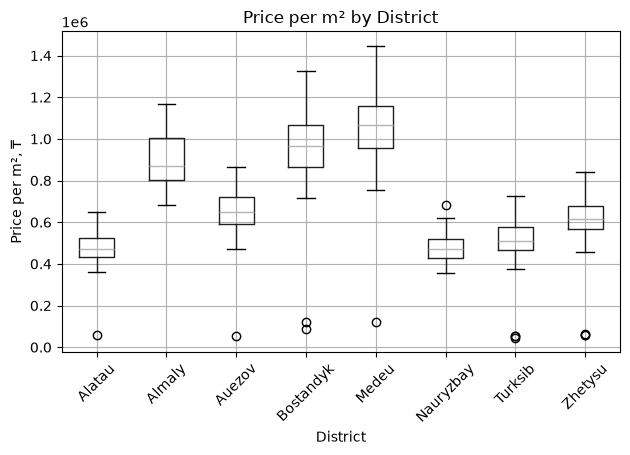

In [43]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="price_per_m2",
    by="district",
    rot=45
)

plt.ylabel("Price per m², ₸")
plt.xlabel("District")
plt.title("Price per m² by District")
plt.suptitle("")

plt.tight_layout()
plt.show()

# Exploratory Data Analysis: Plot 2 — Price vs Area

In this step, we continue Exploratory Data Analysis by examining the relationship between apartment area and total price using a scatter plot. This visualization helps us identify general pricing trends relative to space as well as potential large-area listings.

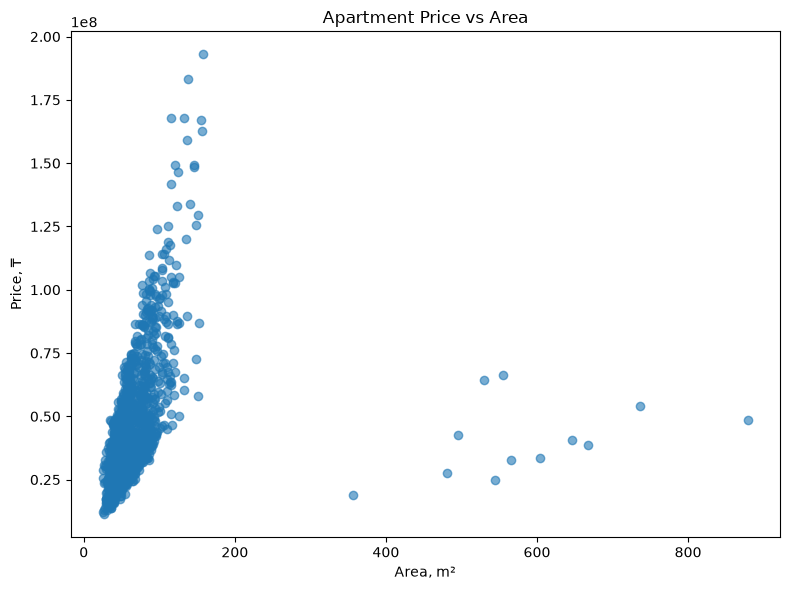

In [44]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["area_m2"],
    df["price_kzt"],
    alpha=0.6
)

plt.xlabel("Area, m²")
plt.ylabel("Price, ₸")
plt.title("Apartment Price vs Area")

plt.tight_layout()
plt.show()

# Exploratory Data Analysis: Plot 3 — Ceiling height

In this step, we complete our Exploratory Data Analysis by examining how ceiling heights vary across different structural building types using boxplots. This visualization helps us identify structural differences across property types and verify the consistency of imputed ceiling heights.

<Figure size 800x600 with 0 Axes>

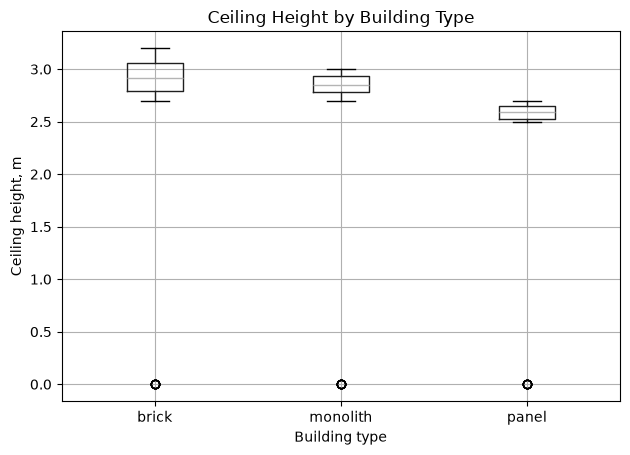

In [45]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column="ceiling_height_m",
    by="building_type"
)

plt.xlabel("Building type")
plt.ylabel("Ceiling height, m")
plt.title("Ceiling Height by Building Type")
plt.suptitle("")

plt.tight_layout()
plt.show()

# Data Cleaning Log Summary

In this step, we compile and display a comprehensive data cleaning log summarizing each transformation applied throughout the workflow. Tracking metrics such as initial row count, final row count, and total modified cells ensures transparency and reproducibility for every data cleaning operation.

In [46]:
cleaning_log = []

# Step 3b - District normalization
rows_before = len(df)

district_before = df["district"].copy()

district_key = (
    df["district"]
    .astype("string")
    .str.strip()
    .str.casefold()
)

df["district"] = district_key.map(district_map)

rows_after = len(df)
changed_cells = (district_before != df["district"]).fillna(False).sum()

cleaning_log.append({
    "Step": "3b",
    "Operation": "Normalize district names",
    "Rows before": rows_before,
    "Rows after": rows_after,
    "Cells changed": int(changed_cells)
})

rows_before = len(df)

area_before = df["area_m2"].copy()
rooms_before = df["rooms"].copy()
price_before = df["price_kzt"].copy()

# Example conversions
df["area_m2"] = pd.to_numeric(df["area_m2"], errors="coerce")

df["rooms"] = (
    df["rooms"]
    .replace({"studio": 1, "Studio": 1})
)

df["rooms"] = pd.to_numeric(df["rooms"], errors="coerce")

df["price_kzt"] = pd.to_numeric(df["price_kzt"], errors="coerce")

rows_after = len(df)

changed_cells = (
    (area_before != df["area_m2"]).fillna(False).sum()
    + (rooms_before != df["rooms"]).fillna(False).sum()
    + (price_before != df["price_kzt"]).fillna(False).sum()
)

cleaning_log.append({
    "Step": "3c",
    "Operation": "Convert text columns to numeric",
    "Rows before": rows_before,
    "Rows after": rows_after,
    "Cells changed": int(changed_cells)
})

cleaning_log_df = pd.DataFrame(cleaning_log)

display(cleaning_log_df)

,Step,Operation,Rows before,Rows after,Cells changed
0,3b,Normalize district names,1080,1080,52
1,3c,Convert text columns to numeric,1080,1080,0


# Exporting the Cleaned Dataset

In [47]:
df.to_csv(
    "data/almaty_apartments_clean.csv",
    index=False
)

print(
    "Saved:",
    "data/almaty_apartments_clean.csv"
)

Saved: data/almaty_apartments_clean.csv
